# Purpose

The purpose of this example notebook is to show how to use the `resin_spectral_analysis` package for spectrum analysis and calculating the normalized dose as a function of `z`.

# Imports

In [1]:
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

import resin_spectral_analysis.data as data
from resin_spectral_analysis.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from resin_spectral_analysis.irradiance import Irradiance
from resin_spectral_analysis.utilities import ArrayParams
from resin_spectral_analysis.normalizeddose import NormalizedDose

# Orientation

## Spectrum data

The `resin_spectral_analysis.data` package contains measured LED emission resin_spectral_analysis and measured absorption resin_spectral_analysis, as well as monomer information necessary to calculate normalized dose. To get an overview of what is in the package, execute the following command:

In [2]:
help(data)

Help on package resin_spectral_analysis.data in resin_spectral_analysis:

NAME
    resin_spectral_analysis.data

PACKAGE CONTENTS
    absorbers (package)
    sources (package)

DATA
    absorbers = {'avobenzone_in_PEGDA_2017-04-13': <resin_spectral_analysis.absorberspectr...
    absorbers_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p...
    material_abbreviations = {'Avobenzone': 'Avo', 'BLS99-2': 'B99', 'BME'...
    monomers = {'HDDA': Monomer(/Users/nordin/Documents/Projects/3D_prin.....
    monomers_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p....
    photoinitiators = {'irgacure819_in_PEGDA_2017-04-13': <resin_spectral_analysis.absorbe...
    photoinitiators_directory = PosixPath('/Users/nordin/Documents/Project...
    sources = {'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectr...
    sources_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p.....

FILE
    /Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectr

The part to pay attention to is under DATA. Specifically, `absorbers`, `monomers`, `photoinitiators`, and `sources`. Note that each of these is a dict, the contents of which is shown below. 

In [3]:
print('Absorbers')
print('---------')
pprint(data.absorbers)
print()

print('Monomers')
print('--------')
pprint(data.monomers)
print()

print('Photoinitiators')
print('---------------')
pprint(data.photoinitiators)
print()

print('Sources')
print('-------')
pprint(data.sources)
print()

Absorbers
---------
{'avobenzone_in_PEGDA_2017-04-13': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa8191ab10>,
 'avobenzone_in_PEGDA_2020-01-20': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa30047e10>,
 'benetex_obplus_in PEGDA_2017-04-13': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa8191ae50>,
 'bls99-2_in_PEGDA_2017-04-13': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa8191acd0>,
 'ideal_uniform_absorber': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa81920090>,
 'martius_yellow_in PEGDA_2020-04-13': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa8191ab50>,
 'nps_in_PEGDA_2017-04-13': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa8191aa50>,
 'octocrylene_in_PEGDA_2017-04-13': <resin_spectral_analysis.absorberspectrum.AbsorberSpectrum object at 0x7faa8192bfd0>,
 'phenazine_in_PEGDA_

To use any of these, it's as simple as accessing the relevant dict with the appropriate key.

### Example: absorber

For example, `data.absorbers['nps_in_PEGDA_2017-04-13']` contains the molar absorptivity of NPS in PEGDA as measured on April 13, 2017.

In [4]:
help(data.absorbers['nps_in_PEGDA_2017-04-13'])

Help on AbsorberSpectrum in module resin_spectral_analysis.absorberspectrum object:

class AbsorberSpectrum(builtins.object)
 |  AbsorberSpectrum(directory)
 |  
 |  Optical absorption spectrum data.
 |  
 |  Attributes:
 |      name (str): Name of absorber.
 |      wavelength (numpy.ndarray): Wavelength array over which molar absorptivity is sampled.
 |      molar_absorptivity (numpy.ndarray): Array of molar absorptivities in units of L/(mole cm).
 |      wavelength_absorbance (numpy.ndarray): Wavelength array over which absorbance is sampled.
 |      absorbance (numpy.ndarray): Measured absorbance values.
 |      parameters (dict): Information loaded from the first line in the molar absorptivity data file.
 |      molar_mass_g_per_mole (float): Molar mass of absorber in grams/mole.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, directory)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  calc_absorbance(self, wavelength)
 |      Given wavelength,

In [5]:
# vars(data.absorbers['nps_in_PEGDA_2017-04-13'])

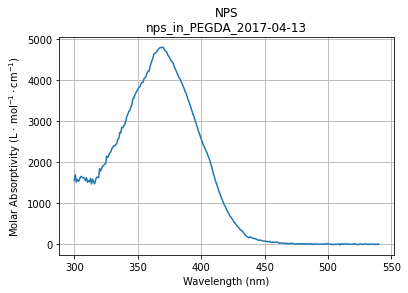

In [6]:
absorber_key = 'nps_in_PEGDA_2017-04-13'
nps = data.absorbers[absorber_key]

fig, ax = plt.subplots()
ax.plot(nps.wavelength, nps.molar_absorptivity)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Molar Absorptivity (L $\cdot$ mol$^{-1} \cdot$cm$^{-1}$)')
ax.set_title(nps.name + '\n' + absorber_key)
ax.grid();

### Example: source

As an example of an LED source, `data.sources['HR3.3_365nm_370nm_short_pass_filter-2020-03-23']` contains the normalized emission spectrum of HR3.3 365 nm LED passed through an Asahi 370 nm short pass filter, which was measured on March 3, 2020.

In [7]:
help(data.sources['HR3.3_365nm_370nm_short_pass_filter-2020-03-23'])

Help on SourceSpectrum in module resin_spectral_analysis.sourcespectrum object:

class SourceSpectrum(builtins.object)
 |  SourceSpectrum(directory)
 |  
 |  Optical spectrum data.
 |  
 |  Attributes:
 |      name (str): Name of source.
 |      wavelength (numpy.ndarray): Array of wavelengths over which source spectrum is sampled.
 |      power (numpy.ndarray): Normalized power.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, directory)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  calc_power(self, wavelength)
 |      Given wavelength, interpolate corresponding power value.
 |      
 |      See numpy.interp documentation for interpolation details.
 |      
 |      Parameters
 |      ----------
 |      wavelength - array_like (can be single value or 1D list/numpy.array of values)
 |      
 |      Returns
 |      -------
 |      single value or 1D numpy array corresponding to shape of wavelength
 |  
 |  ------------------------------------------

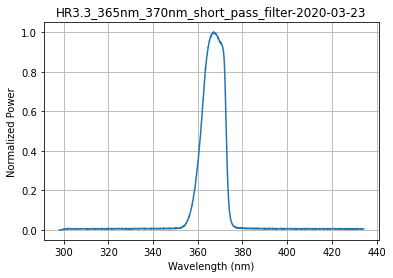

In [8]:
source_key = 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23'
source = data.sources[source_key]

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Normalized Power')
ax.set_title(source.name)
ax.grid();

# Compare absorber and source

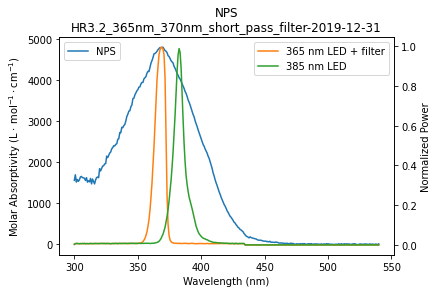

In [24]:
source_385nm = data.sources['HR2_385nm_2020-03-23']

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(nps.wavelength, nps.molar_absorptivity, label='NPS')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Molar Absorptivity (L $\cdot$ mol$^{-1} \cdot$cm$^{-1}$)')
ax.set_title(nps.name + '\n' + source.name)
ax2.plot(nps.wavelength, source.calc_power(nps.wavelength), c='C1', label='365 nm LED + filter')
ax2.plot(nps.wavelength, source_385nm.calc_power(nps.wavelength), c='C2', label='385 nm LED')
ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
ax2.legend(loc='upper right');

Note the use of `source.calc_power(nps.wavelength)` and `source_385nm.calc_power(nps.wavelength)` in plotting the source resin_spectral_analysis, which samples the source resin_spectral_analysis at the same wavelengths and over the same wavelength range as the nps absorption data.

# Construct a resin

To construct a resin, we need one or more monomers, one or more absorbers, and a photoinitiator. As an example, let's construct a 0.38% avobenzone resin in PEGDA with 1% Irgacure 819.

The process of constructing a resin involves the following steps:

1. Define all constituent materials
2. Create a `Resin` object using the consituent materials.

## Define constituent materials

In [9]:
# Monomer
pegda = ResinConstituentMonomer(
    material=data.monomers['PEGDA'], 
    concentration_percent_monomer=100
)

# Absorber
avobenzone = ResinConstituentAbsorber(
    material=data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    concentration_ww_percent=0.38
)

# Photoinitiator
irgacure819 = ResinConstituentAbsorber(
    material=data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    concentration_ww_percent=1.0
)

In the code above, note that we use the class `ResinConstituentAbsorber` for both absorbers and photoinitiators because their optical effect on the resin is the same, i.e., they each absorb light with a particular spectral absorbance.

## Create resin

In [10]:
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)

# Define an Irradiance object

An `Irradiance` object calculates the irradiance at one or more z positions as a function of wavelength for a particular combination of resin and source.

In [11]:
# Source
source = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']

# Irradiance
irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

In [12]:
help(ArrayParams)

Help on class ArrayParams in module resin_spectral_analysis.utilities:

class ArrayParams(builtins.tuple)
 |  ArrayParams(min_value: float, max_value: float, num_pnts: int)
 |  
 |  Container with named attributes for making 1D arrays of linearly spaced values.
 |  Intended for use with numpy.linspace.
 |  
 |  Attributes:
 |      min_value (float): Minimum value in array
 |      max_value (float): Maximum value in array
 |      num_pnts (int): number of values in array
 |  
 |  Method resolution order:
 |      ArrayParams
 |      builtins.tuple
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __getnewargs__(self)
 |      Return self as a plain tuple.  Used by copy and pickle.
 |  
 |  __repr__(self)
 |      Return a nicely formatted representation string
 |  
 |  _asdict(self)
 |      Return a new OrderedDict which maps field names to their values.
 |  
 |  _replace(_self, **kwds)
 |      Return a new ArrayParams object replacing specified fields with new values
 |  
 |

Note that `ArrayParams` returns an array of linearly spaced wavelength values from 300 to 440 nm, with 281 total values in the array.

# Calculate normalized dose

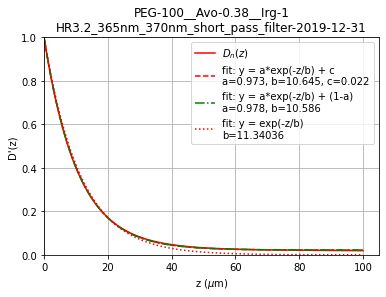

In [13]:
# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)

# Plot
norm_dose.plot(title=(norm_dose.irradiance.resin.name + "\n" + norm_dose.irradiance.source.name));

# Putting it all together

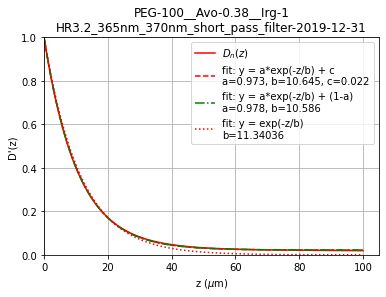

In [14]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    0.38
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)

# Source
source = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']

# Irradiance
irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)

norm_dose.plot(title=(norm_dose.irradiance.resin.name + "\n" + norm_dose.irradiance.source.name));

# OLD - IGNORE

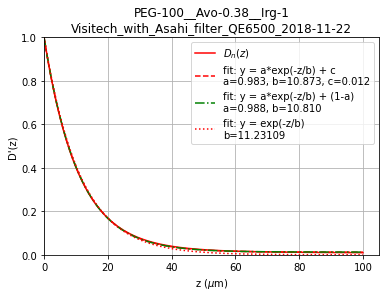

In [16]:
# Source
source2 = data.sources['Visitech_with_Asahi_filter_QE6500_2018-11-22']

# Irradiance
irradiance2 = Irradiance(source=source2, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params2 = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose2 = NormalizedDose(irradiance=irradiance2, z_array_params=z_array_params2)

norm_dose2.plot(title=(norm_dose2.irradiance.resin.name + "\n" + norm_dose2.irradiance.source.name));